CODTECH IT SOLUTIONS - TASK 4

Predictive Modeling: SMS Spam Detection

Intern: Sumedha

ID: CTIS8362

Domain: Python Programming

Objective: To build and evaluate a Machine Learning model using Scikit-Learn to classify messages into "Ham" (Normal) or "Spam".

In [3]:
# Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set visualization style
sns.set(style="whitegrid")
print("Environment Setup Complete")

Environment Setup Complete


Step 1: Data Acquisition

We are using the SMS Spam Collection dataset, a public dataset containing over 5,000 labeled SMS messages.

In [4]:
# Load Dataset from public URL
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

# Display first few rows
print("Dataset Head:")
display(df.head())

# Basic info
print("\nDataset Information:")
df.info()

Dataset Head:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


Step 2: Exploratory Data Analysis (EDA)

We analyze the distribution of the classes to see if our dataset is balanced.

/tmp/ipykernel_990/2757420850.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='mako')


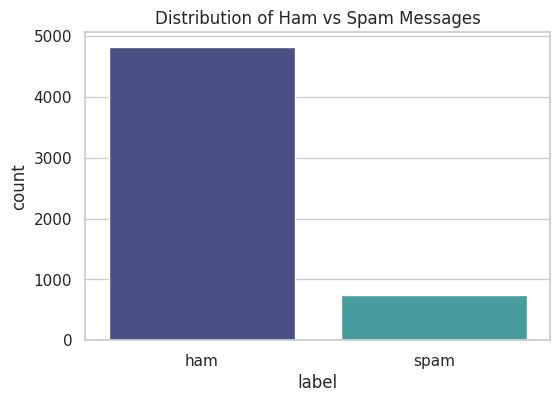

Class Percentages:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [5]:
# Visualize Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', palette='mako')
plt.title('Distribution of Ham vs Spam Messages')
plt.show()

# Calculate Percentages
print("Class Percentages:")
print(df['label'].value_counts(normalize=True) * 100)

Step 3: Data Preprocessing & Feature Engineering

1. Label Encoding: Convert 'ham' to 0 and 'spam' to 1.

2. Text Vectorization: We use TF-IDF (Term Frequency-Inverse Document Frequency) to convert text into mathematical features. This is more advanced than simple word counting as it weights unique keywords.

In [6]:
# Encode Labels
df['label_num'] = df.label.map({'ham': 0, 'spam': 1})

# Define Features and Target
X = df.message
y = df.label_num

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorization
tfidf = TfidfVectorizer(stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"X_train shape: {X_train_tfidf.shape}")

X_train shape: (4457, 7441)


Step 4: Model Training

We choose the Multinomial Naive Bayes classifier. It is the industry standard for text-based classification due to its speed and high accuracy with discrete features.


In [7]:
# Initialize and Fit Model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Generate Predictions
y_pred = model.predict(X_test_tfidf)
print("Model Training Complete")

Model Training Complete


Step 5: Model Evaluation

We evaluate the model using the Confusion Matrix (to see errors) and the Classification Report (to see Precision, Recall, and F1-Score).

Accuracy Score: 0.9785

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       1.00      0.84      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



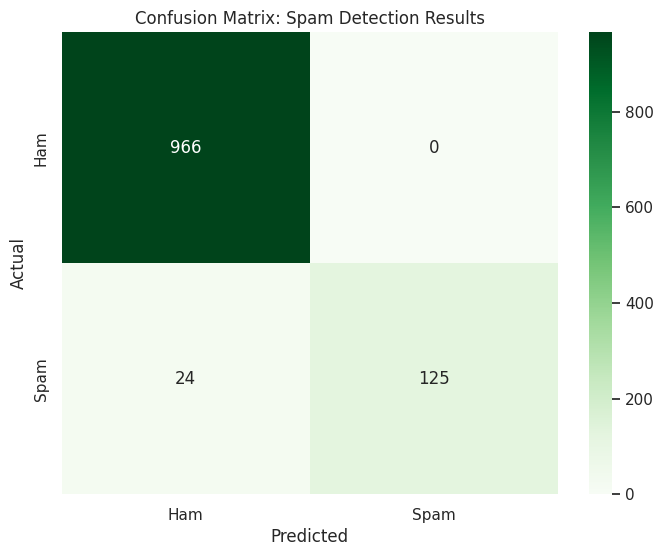

In [8]:
# Performance Report
print("Accuracy Score:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Spam Detection Results')
plt.show()

Step 6: Live Prediction (Inference)

Testing the model with custom inputs to simulate a real-world application.

In [9]:
def test_message(msg):
    # Transform the input text into the same TF-IDF format as our training data
    vec = tfidf.transform([msg])
    # Use the model to predict (0 for Ham, 1 for Spam)
    prediction = model.predict(vec)
    result = "SPAM 🚩" if prediction[0] == 1 else "HAM (Safe) ✅"
    print(f"Message: '{msg}' \nResult: {result}\n")

# --- Testing the Model with Sample Inputs ---
test_message("Congratulations! You've won a $1,000 Walmart gift card. Click here to claim now.")
test_message("Hey, are we still meeting for coffee at 5 PM today?")
test_message("URGENT: Your account has been suspended. Verify your details at this link immediately.")
test_message("I'll be a bit late for the meeting, please start without me.")

Message: 'Congratulations! You've won a $1,000 Walmart gift card. Click here to claim now.' 
Result: SPAM 🚩

Message: 'Hey, are we still meeting for coffee at 5 PM today?' 
Result: HAM (Safe) ✅

Message: 'URGENT: Your account has been suspended. Verify your details at this link immediately.' 
Result: SPAM 🚩

Message: 'I'll be a bit late for the meeting, please start without me.' 
Result: HAM (Safe) ✅



Project Conclusion

In this project, we successfully developed a Machine Learning model to classify SMS messages as Spam or Ham.